# RAG on LangChain p1

Retrieval-Augmented Generation (RAG) is an artificial intelligence technique that combines generative language models with information retrieval mechanisms to provide more accurate and up-to-date responses.

This approach allows language models to access external information in real time, reducing the incidence of “hallucinations” and increasing the reliability of the generated responses.

The RAG process involves four main steps [ref](https://en.wikipedia.org/wiki/Retrieval-augmented_generation?utm_source=chatgpt.com):​

1. Indexing: Relevant data is converted into vector representations and stored in a specialized database.

2. Retrieval: When a query is made, the system retrieves the most relevant documents from the database.

3. Augmentation: The retrieved information is incorporated into the original prompt to provide additional context to the language model.

4. Generation: The language model generates a response based both on its prior knowledge and the newly retrieved information.


These steps are represented in the image below:

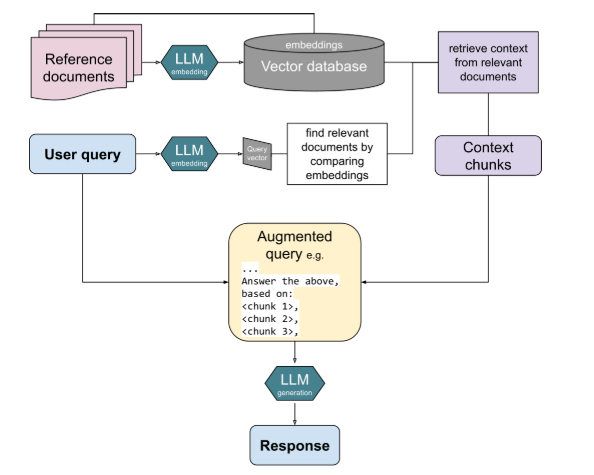

This technique has been adopted by various companies to improve the accuracy and relevance of AI system responses, especially in domains that require up-to-date or specific information.

In summary, RAG represents a significant advancement in how language models can be enhanced with external information, providing more accurate and reliable answers.

### RAG Applications

* **External data querying**: Allows the use of datasets outside the model during response generation.
* **Reduction of hallucinations**: By anchoring on real documents, RAG increases the reliability of responses.
* **Interaction with specific documents**: Answers questions about PDFs, video transcripts, and other textual content.
* **Smart contextual retrieval**: Uses LLMs to automatically search for and incorporate relevant information from external sources.

### References

This lesson was based on the following references:

* [Course DeepLearningAI](https://learn.deeplearning.ai/courses/langchain-chat-with-your-data/lesson/snupv/introduction)
* [LangChain retrieval overview](https://docs.langchain.com/oss/python/langchain/retrieval)
* [LangChain semantic search tutorial](https://docs.langchain.com/oss/python/langchain/knowledge-base)
* [Together.AI](https://www.together.ai/blog/rag-tutorial-langchain)

In [ ]:
!pip install -qU dotenv langchain_openai langchain-google-genai -U wikipedia -U numexpr langchain_community langgraph DateTime pypdf langchain-chroma langchain_nvidia_ai_endpoints langchain_openrouter langsmith
!wget -r -np -nH --cut-dirs=3 -R "index.html*" https://github.com/langchain-ai/langchain/raw/master/docs/docs/example_data/

In [ ]:
from IPython.display import Markdown
import getpass
import os

from dotenv import load_dotenv, find_dotenv
_ = load_dotenv(find_dotenv()) # read local .env file

In [ ]:
from google.colab import userdata
import os

os.environ["LANGCHAIN_TRACING_V2"] = "true"
os.environ["LANGCHAIN_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGCHAIN_API_KEY"] = userdata.get('LANGCHAIN_API_KEY')
os.environ["LANGCHAIN_PROJECT"] = "LLM Class"

In [ ]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
from langchain_openrouter import ChatOpenRouter
from langchain_nvidia_ai_endpoints import ChatNVIDIA
from google.colab import userdata

def get_model_name(model_name, temperature=0):
    if model_name == "gemini": # https://ai.google.dev/gemini-api/docs/rate-limits?hl=pt-br
        if "GOOGLE_API_KEY" not in os.environ: # https://ai.google.dev/gemini-api/docs/api-key
            os.environ["GOOGLE_API_KEY"] = userdata.get('GOOGLE_API_KEY')
        llm = ChatGoogleGenerativeAI(
            # model="gemini-2.5-pro", # max 50 / dia
            model="gemini-2.5-flash", # max 1500 / dia
            temperature=temperature,
        )
    elif model_name == "openai":  # https://platform.openai.com
        if "OPENAI_API_KEY" not in os.environ:
            os.environ["OPENAI_API_KEY"] = userdata.get('OPENAI_API_KEY')
        llm = ChatOpenAI(
            model="gpt-4o-mini",
            temperature=temperature,
        )
    elif model_name == "openrouter": # https://openrouter.ai/workspaces/default/
        if "OPENROUTER_API_KEY" not in os.environ:
            os.environ["OPENROUTER_API_KEY"] = userdata.get('OPENROUTER_API_KEY')

        llm = ChatOpenRouter(
            model="openrouter/free",
            api_key=os.environ["OPENROUTER_API_KEY"],
            temperature=temperature,
        )
    elif model_name == "nvidia": # https://build.nvidia.com/explore/discover
       if "NVIDIA_API_KEY" not in os.environ:
           os.environ["NVIDIA_API_KEY"] = userdata.get('NVIDIA_API_KEY')
       llm = ChatNVIDIA(
           model="meta/llama-4-maverick-17b-128e-instruct",
           api_key=os.environ["NVIDIA_API_KEY"],
           temperature=temperature,
       )

    return llm

llm = get_model_name('nvidia')
resp = llm.invoke("Olá")
print(resp.content)

Olá! Como posso ajudar você hoje?


### RAG in LangChain

LangChain offers several features that simplify the implementation of Retrieval-Augmented Generation (RAG) systems through a modular framework.

This approach allows for easy integration of components such as indexing (document loading, splitting, vector storage), retrieval, augmentation, and response generation with language models.

In the image below, we illustrate the basic sequence to build a RAG system using LangChain:


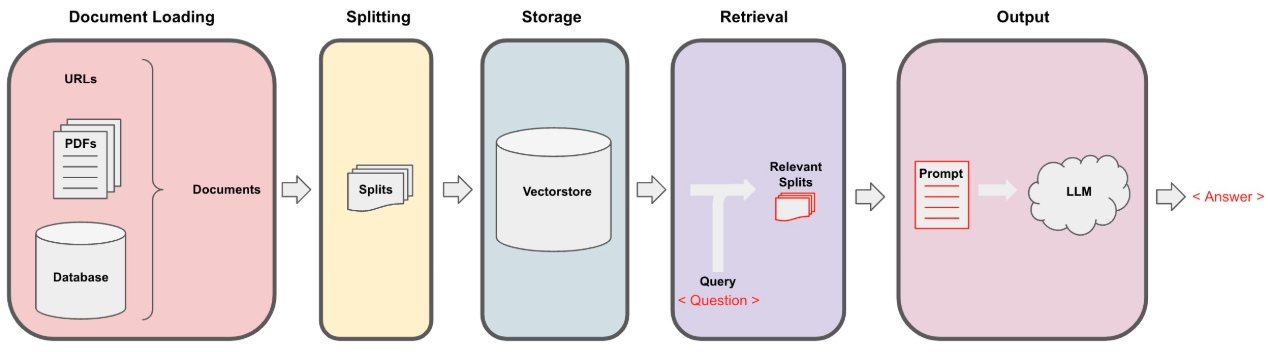

# Section 5. Indexing

In this lesson, we will explore each of these components with the goal of building a system capable of interacting intelligently with our documents.

## 5.1 Documents and Document Loaders

The LangChain ecosystem offers a variety of document loaders that integrate with hundreds of common sources, making it easy to incorporate data from these sources into AI applications. You can consult the [official documentation](https://python.langchain.com/docs/how_to/#document-loaders) to see the complete list of available loaders.

In this lesson, we will create our RAG system using the same file used in the [official LangChain tutorial](https://python.langchain.com/docs/tutorials/retrievers/) on RAG. The file can be accessed through this [link](https://github.com/langchain-ai/langchain/tree/master/docs/docs/example_data), or directly via Blackboard.

In the cell below, we will use the `PyPDFLoader` class to load the document.


In [ ]:
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader("nke-10k-2023.pdf")
pages = loader.load()

Each item in the returned list is an instance of the `Document` class, representing a page of the PDF, as illustrated in the cell below.

The `Document` class has the `page_content` attribute, which contains the text of the page, and the `metadata` attribute, which stores information about the document, such as the source and page number.

In the cell below, we also print the total number of characters in the text as a reference for the document's size. Finally, we display the metadata of the first page, which includes, for example, the software used to generate the PDF and the creation date.


In [ ]:
print("Number of pages:", len(pages))
print('____')
page = pages[0]
print(page.page_content[0:500])
print('____')
print('Total number of caracters:', sum([len(p.page_content) for p in pages]))
print(page.metadata)

Number of pages: 107
____
Table of Contents
UNITED STATES
SECURITIES AND EXCHANGE COMMISSION
Washington, D.C. 20549
FORM 10-K
(Mark One)
☑ ANNUAL REPORT PURSUANT TO SECTION 13 OR 15(D) OF THE SECURITIES EXCHANGE ACT OF 1934
FOR THE FISCAL YEAR ENDED MAY 31, 2023
OR
☐ TRANSITION REPORT PURSUANT TO SECTION 13 OR 15(D) OF THE SECURITIES EXCHANGE ACT OF 1934
FOR THE TRANSITION PERIOD FROM                         TO                         .
Commission File No. 1-10635
NIKE, Inc.
(Exact name of Registrant as specified in its 
____
Total number of caracters: 376332
{'producer': 'EDGRpdf Service w/ EO.Pdf 22.0.40.0', 'creator': 'EDGAR Filing HTML Converter', 'creationdate': '2023-07-20T16:22:00-04:00', 'title': '0000320187-23-000039', 'author': 'EDGAR Online, a division of Donnelley Financial Solutions', 'subject': 'Form 10-K filed on 2023-07-20 for the period ending 2023-05-31', 'keywords': '0000320187-23-000039; ; 10-K', 'moddate': '2023-07-20T16:22:08-04:00', 'source': 'nke-10k-2023.pdf', 

Another commonly used document loader is the `WebBaseLoader`, which allows loading information directly from web pages to be used in processing with LangChain.

In [ ]:
import bs4
from langchain_community.document_loaders import WebBaseLoader

# Only keep post title, headers, and content from the full HTML.
# bs4_strainer = bs4.SoupStrainer(class_=("post-title", "post-header", "post-content"))
loader = WebBaseLoader(
    web_paths=("https://python.langchain.com/docs/tutorials/retrievers/",),
    # bs_kwargs={"parse_only": bs4_strainer},
)
docs = loader.load()

There are many other document loaders available in LangChain, including those for YouTube, Notion, Google Drive, Social Platforms, and more.

* [LangChain Document Loaders](https://docs.langchain.com/oss/python/integrations/document_loaders)

## 5.2 Document Splitting

As we know, documents can vary greatly in length — from short paragraphs to entire books. When the content is too long, passing it entirely to an LLM can lead to issues like hallucinations or loss of context. For this reason, it is recommended to split the document into smaller parts and index them individually. This process is known as document splitting.

Document splitting is the technique of breaking down a long text into smaller, more manageable chunks. This step is essential when processing extensive documents, as it allows for more efficient information retrieval and more accurate response generation by language models.

LangChain offers several splitting strategies, as outlined in this [link](https://docs.langchain.com/oss/python/integrations/splitters), including:

### `RecursiveCharacterTextSplitter`:

This strategy splits the text based on a maximum character length, recursively. In other words, it tries to preserve the text's structure (such as paragraphs and sentences) before resorting to arbitrary cuts.

* It is the most recommended option for generic texts.

### `CharacterTextSplitter`:

This method performs splitting by looking for a specific character, such as spaces, line breaks, or punctuation marks. It is useful when the content has a clear structure, such as lists or records.

### `TokenTextSplitter`:

Splits the text based on a maximum number of tokens — which are the input units for language models.

* A token is typically about 4 characters in English, so 1,000 tokens correspond to approximately 750 words.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter, CharacterTextSplitter, TokenTextSplitter
chunk_size =26
chunk_overlap = 4
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap
)
c_splitter = CharacterTextSplitter(
    chunk_size=chunk_size,
    chunk_overlap=chunk_overlap
)
t_splitter = TokenTextSplitter(chunk_size=1, chunk_overlap=0)

This cell defines the three types of text splitters, all configured with the same segment size `chunk_size` and an overlap `chunk_overlap` of 4 characters.

In [ ]:
text1 = 'abcdefghijklmnopqrstuvwxyz'
r_splitter.split_text(text1)

['abcdefghijklmnopqrstuvwxyz']

When creating a larger text, we can observe that the `chunk_size` parameter defines the size of each segment, while the `chunk_overlap` ensures that part of the content from the previous segment is retained in the next one, helping to preserve the context between sections.

In [ ]:
text2 = 'abcdefghijklmnopqrstuvwxyzabcdefg'
r_splitter.split_text(text2)

['abcdefghijklmnopqrstuvwxyz', 'wxyzabcdefg']

Spaces count as characters...

In [ ]:
text3 = "a b c d e f g h i j k l m n o p q r s t u v w x y z"
r_splitter.split_text(text3)

['a b c d e f g h i j k l m', 'l m n o p q r s t u v w x', 'w x y z']

Now let's test the `CharacterTextSplitter` in action. By default, the character used is `\n\n`.

In [ ]:
print(c_splitter.split_text(text3))
c_splitter.split_text(text3 + '\n\n' + text3)

['a b c d e f g h i j k l m n o p q r s t u v w x y z']


['a b c d e f g h i j k l m n o p q r s t u v w x y z',
 'a b c d e f g h i j k l m n o p q r s t u v w x y z']

The `TokenTextSplitter` was defined as breaking tokens into blocks of 1 token, so we can check the size of a token in the cell below.

In [ ]:
t_splitter.split_text(text2)

['abc',
 'def',
 'gh',
 'ij',
 'kl',
 'mn',
 'op',
 'q',
 'r',
 'st',
 'uv',
 'w',
 'xy',
 'z',
 'abc',
 'def',
 'g']

Lets try for a bigger example, this text has 496 characters

In [ ]:
some_text = """When writing documents, writers will use document structure to group content. \
This can convey to the reader, which idea's are related. For example, closely related ideas \
are in sentances. Similar ideas are in paragraphs. Paragraphs form a document. \n\n  \
Paragraphs are often delimited with a carriage return or two carriage returns. \
Carriage returns are the "backslash n" you see embedded in this string. \
Sentences have a period at the end, but also, have a space.\
and words are separated by space."""

len(some_text)

496

In the cell below, we will test multiple separators: double line breaks, single lines, spaces, and, as a last resort, direct character splitting (respectively). This helps preserve language structures.

```python
        separators=["\n\n", "\n", " ", ""]
```

In [ ]:
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=450,
    chunk_overlap=0,
    separators=["\n\n", "\n", " ", ""]
)

r_splitter.split_text(some_text)

["When writing documents, writers will use document structure to group content. This can convey to the reader, which idea's are related. For example, closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document.",
 'Paragraphs are often delimited with a carriage return or two carriage returns. Carriage returns are the "backslash n" you see embedded in this string. Sentences have a period at the end, but also, have a space.and words are separated by space.']

Next, we will reduce the chunk\_size a bit and add the period as a separator.

The period `.` is added as a new splitting point, which helps preserve entire sentences within the chunks.


In [ ]:
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=150,
    chunk_overlap=0,
    separators=["\n\n", "\n", "\. ", " ", ""]
)
r_splitter.split_text(some_text)

<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_8179/158012430.py:4: SyntaxWarning: invalid escape sequence '\.'
  separators=["\n\n", "\n", "\. ", " ", ""]


["When writing documents, writers will use document structure to group content. This can convey to the reader, which idea's are related. For example,",
 'closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document.',
 'Paragraphs are often delimited with a carriage return or two carriage returns. Carriage returns are the "backslash n" you see embedded in this',
 'string. Sentences have a period at the end, but also, have a space.and words are separated by space.']

In [ ]:
r_splitter = RecursiveCharacterTextSplitter(
    chunk_size=150,
    chunk_overlap=0,
    separators=["\n\n", "\n", "(?<=\. )", " ", ""]
)
r_splitter.split_text(some_text)

<>:4: SyntaxWarning: invalid escape sequence '\.'
<>:4: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipykernel_8179/2945222903.py:4: SyntaxWarning: invalid escape sequence '\.'
  separators=["\n\n", "\n", "(?<=\. )", " ", ""]


["When writing documents, writers will use document structure to group content. This can convey to the reader, which idea's are related. For example,",
 'closely related ideas are in sentances. Similar ideas are in paragraphs. Paragraphs form a document.',
 'Paragraphs are often delimited with a carriage return or two carriage returns. Carriage returns are the "backslash n" you see embedded in this',
 'string. Sentences have a period at the end, but also, have a space.and words are separated by space.']

Now let's split our actual document. We will use the `RecursiveCharacterTextSplitter` to split our document into smaller chunks, generating multiple sub-documents. The overlap of 200 characters helps maintain cohesion between the sections.

In the next section, we will also attach a stable `chunk_id` to each split. This makes it easier to inspect retrieved passages, combine dense and sparse retrieval, and later evaluate retrieval quality.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # chunk size (characters)
    chunk_overlap=200,  # chunk overlap (characters)
    add_start_index=True,  # track index in original document
)
all_splits = text_splitter.split_documents(docs)

print(f"Split blog post into {len(all_splits)} sub-documents.")

Split blog post into 45 sub-documents.


## 5.3 Vector Store

Vector stores are specialized databases that store embedding vectors. As we saw earlier, embedding vectors capture the semantic meaning of data such as text, images, or audio. Furthermore, elements with similar meanings are "close" to each other in the N-dimensional space of embedding vectors. Thus, vector stores allow information to be retrieved based on semantic similarity, not just exact keywords. This is illustrated in the image below:


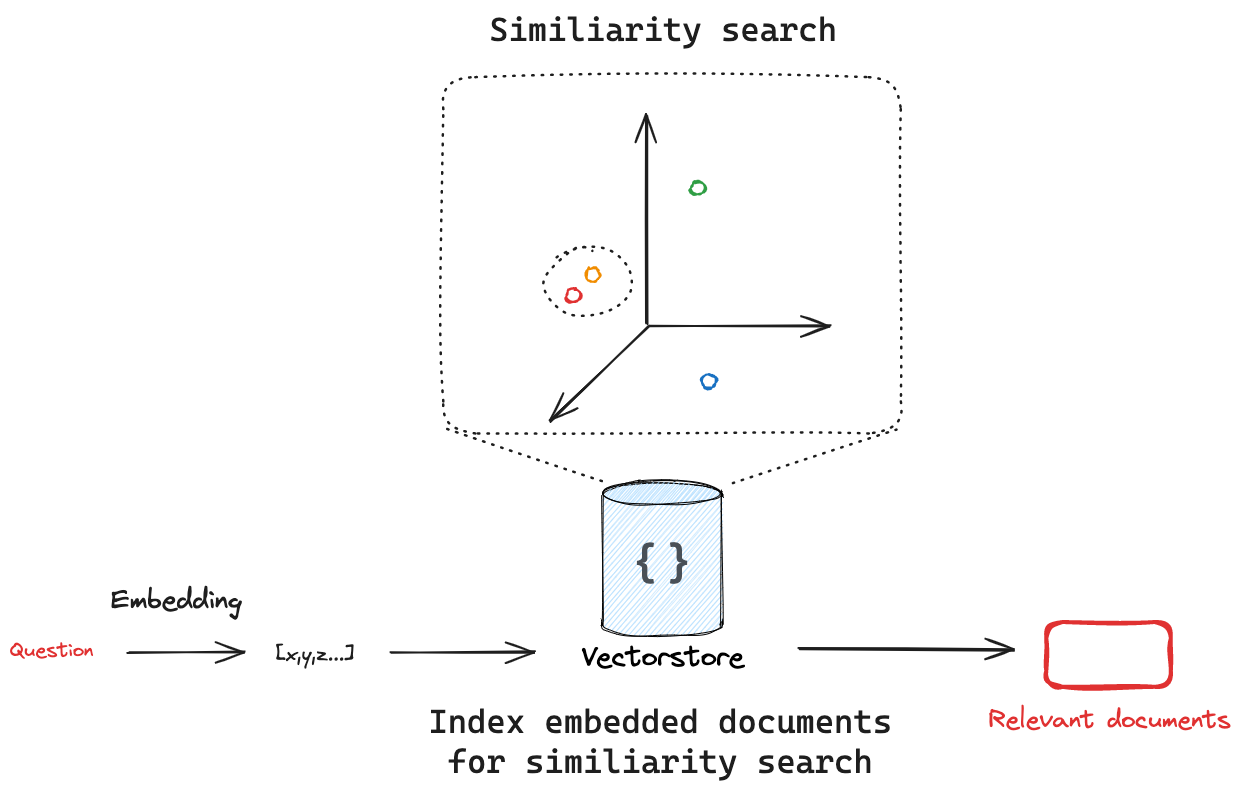

## Vector Stores in LangChain

In LangChain, vector stores are central components of RAG (Retrieval-Augmented Generation) systems. After splitting documents into smaller parts, each chunk is converted into a vector and stored. When a question is asked, it is also transformed into a vector, and the most semantically similar documents are retrieved to provide context to the LLM.

LangChain offers integration with several backends, such as FAISS, Chroma, Pinecone, Weaviate, among others, as discussed in this [vector store overview](https://docs.langchain.com/oss/python/integrations/vectorstores).

First, let's revisit the code by loading and splitting the document again.

In [ ]:
from langchain_community.document_loaders import PyPDFLoader
loader = PyPDFLoader("nke-10k-2023.pdf")
docs = loader.load()

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # chunk size (characters)
    chunk_overlap=200,  # chunk overlap (characters)
    add_start_index=True,  # track index in original document
)
all_splits = text_splitter.split_documents(docs)

for i, doc in enumerate(all_splits):
    doc.metadata["chunk_id"] = f"nike_chunk_{i}"

print(f"Split PDF into {len(all_splits)} sub-documents.")
print("Example chunk id:", all_splits[0].metadata["chunk_id"])

Split PDF into 516 sub-documents.
Example chunk id: nike_chunk_0


Now that we have a set of sub-documents, we need embedding vectors to represent them, so we can later search them. These embeddings will be stored in a vector store.

Let's begin by taking a closer look at embeddings.

In [ ]:
from langchain_nvidia_ai_endpoints import NVIDIAEmbeddings

embeddings = NVIDIAEmbeddings(
    model="nvidia/nv-embed-v1",
    api_key=os.environ["NVIDIA_API_KEY"]
)

Now let's test the concept of proximity in the vector embedding space. In the next cells, we will define three short sentences. By reading their content, we notice that `sentence1` and `sentence2` seem semantically closer to each other than to `sentence3`. But is that also true in the embedding space?


In [ ]:
sentence1 = "i like dogs"
sentence2 = "i like canines"
sentence3 = "the weather is ugly outside"

embedding1 = embeddings.embed_query(sentence1)
embedding2 = embeddings.embed_query(sentence2)
embedding3 = embeddings.embed_query(sentence3)

In [ ]:
import numpy as np
from numpy.linalg import norm

def cosine_similarity(a, b):
    return np.dot(a, b) / (norm(a) * norm(b))

print(cosine_similarity(embedding1, embedding2))
print(cosine_similarity(embedding1, embedding3))
print(cosine_similarity(embedding2, embedding3))

0.6540352292368778
0.0033863689935442233
-0.013042350117031259


These results indicate exactly what we expected:

* `sentence1` vs `sentence2`: 0.654 → Very close semantically.
* `sentence1` vs `sentence3`: 0.003
* `sentence2` vs `sentence3`: -0.013

In other words, `sentence1` and `sentence2` share more meaning with each other than with `sentence3`, and we can say that the model reflected this well in the embedding space.


Now that we better understand what embeddings are and how to convert sentences into their vector representations, let's learn how to use them in a Vector Store.

Just like other databases, there are several services that offer online vector stores, but it is also possible to store them locally. LangChain provides integration with a wide variety of vector stores, allowing users to easily switch between different implementations. You can check out the full list at this [link](https://docs.langchain.com/oss/python/integrations/vectorstores).

In this activity, we will focus only on local options. There are two main alternatives:

1. Storing vectors in memory, temporarily.
2. Saving them locally using [Chroma](https://docs.langchain.com/oss/python/integrations/vectorstores/chroma/), an open-source vector database designed for developers, with a focus on productivity and simplicity.

We will demonstrate both alternatives in the following cells.

#### Save locally

In [ ]:
from langchain_chroma import Chroma

vector_store = Chroma(
    collection_name="example_collection",
    embedding_function=embeddings,
    persist_directory="./chroma_langchain_db",  # Where to save data locally, remove if not necessary
)

#### Save in memory

In [ ]:
from langchain_core.vectorstores import InMemoryVectorStore

vector_store = InMemoryVectorStore(embeddings)

Now we can use it to store all document splits. In the cell below, we added a delay to avoid exceeding our quota.

In [ ]:
import time
from langchain_core.vectorstores import InMemoryVectorStore
from langchain_nvidia_ai_endpoints import NVIDIAEmbeddings

embeddings = NVIDIAEmbeddings(
    model="nvidia/nv-embed-v1",
    api_key=os.environ["NVIDIA_API_KEY"]
)
vector_store = InMemoryVectorStore(embeddings)

all_ids = []

for i in range(0, len(all_splits), 20):
    batch = all_splits[i:i + 20]

    while True:
        try:
            ids = vector_store.add_documents(documents=batch)
            all_ids.extend(ids)
            print(f"Batch {i // 20 + 1}: {len(ids)} documents added")
            break
        except Exception as e:
            if "429" in str(e) or "RESOURCE_EXHAUSTED" in str(e):
                print("RESOURCE_EXHAUSTED. Waiting 30 segundos...")
                time.sleep(30)
            else:
                raise

print(f"Added {len(all_ids)} documents to the vector store.")

Batch 1: 20 documents added
Batch 2: 20 documents added
Batch 3: 20 documents added
Batch 4: 20 documents added
Batch 5: 20 documents added
Batch 6: 20 documents added
Batch 7: 20 documents added
Batch 8: 20 documents added
Batch 9: 20 documents added
Batch 10: 20 documents added
Batch 11: 20 documents added
Batch 12: 20 documents added
Batch 13: 20 documents added
Batch 14: 20 documents added
Batch 15: 20 documents added
Batch 16: 20 documents added
Batch 17: 20 documents added
Batch 18: 20 documents added
Batch 19: 20 documents added
Batch 20: 20 documents added
Batch 21: 20 documents added
Batch 22: 20 documents added
Batch 23: 20 documents added
Batch 24: 20 documents added
Batch 25: 20 documents added
Batch 26: 16 documents added
Added 516 documents to the vector store.


Great! With this, we have completed the first part of a RAG flow, the Indexing. In the next notebook, we will study retrieval, generation, mixed retrieval with BM25, and a lightweight evaluation loop.